<a href="https://colab.research.google.com/github/shvdkam/customer-behavior-sql-analysis/blob/main/Are_Entry_Level_Data_Analyst_Jobs_Really_Entry_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Are Entry-Level Data Analyst Jobs Really Entry-Level?

## Project Overview

This project investigates whether vacancies labelled as Associate are genuinely suitable for entry-level Data Analyst candidates.

Instead of relying only on descriptive statistics, the project introduces a custom Entry-Level Friendliness Index (ELFI) that evaluates each vacancy using multiple dimensions.

## Dataset

- 12,894 job postings
- Data Analyst related positions
- Job descriptions
- Technical skills
- Seniority levels
- Work arrangements

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Regular Expressions

In [375]:
import re

import pandas as pd
import matplotlib.pyplot as plt

In [376]:
DATA_PATH = "/content/postings.csv"

df = pd.read_csv(DATA_PATH)

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Number of rows: 12,894
Number of columns: 11


,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,"Data Analyst-SQL, Tableau",Zortech Solutions,"Mountain View, CA",https://www.linkedin.com/jobs/data-analyst-jobs,2023-12-20,Bloomington,United States,Associate,Onsite,NaN,NaN
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop..."
2,Business Systems Analyst `1,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/business-sy...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Overview\nThe Business Systems Analyst 1 perfo...,"Business Analysis, Technical Writing, Software..."
3,Senior VAT and Indirect Tax Analyst,Epic,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-vat-...,2023-12-20,Bloomington,United States,Mid senior,Onsite,We're looking for an experienced tax professio...,"Accounting, Finance, VAT/GST tax regimes, US a..."
4,Senior HRIS Analyst (Timekeeping and Payroll),Nordson Corporation,Greater Bloomington Area,https://www.linkedin.com/jobs/view/senior-hris...,2023-12-20,Bloomington,United States,Mid senior,Remote,Collaboration drives Nordson’s success as a ma...,"Workday HCM, UKG Dimensions, Ceridian Dayforce..."


In [377]:
if "job level" in df.columns:
    df = df.rename(columns={"job level": "job_level"})

df.columns.tolist()

['job_title',
 'company',
 'job_location',
 'job_link',
 'first_seen',
 'search_city',
 'search_country',
 'job_level',
 'job_type',
 'job_summary',
 'job_skills']

## 1. Data Understanding

Before starting the analysis, the dataset was explored to understand its structure, quality, and completeness.

The dataset contains job postings collected from online recruitment platforms. Each record includes the job title, company, location, seniority level, work arrangement, job description, and technical skills.

In [378]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12894 entries, 0 to 12893
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       12894 non-null  object
 1   company         12894 non-null  object
 2   job_location    12894 non-null  object
 3   job_link        12894 non-null  object
 4   first_seen      12894 non-null  object
 5   search_city     12894 non-null  object
 6   search_country  12894 non-null  object
 7   job_level       12894 non-null  object
 8   job_type        12894 non-null  object
 9   job_summary     12851 non-null  object
 10  job_skills      12705 non-null  object
dtypes: object(11)
memory usage: 1.1+ MB


In [379]:
df.isna().sum()

,0
job_title,0
company,0
job_location,0
job_link,0
first_seen,0
search_city,0
search_country,0
job_level,0
job_type,0
job_summary,43


In [380]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate job links: {df['job_link'].duplicated().sum()}")

Duplicate rows: 0
Duplicate job links: 0


In [381]:
df.nunique()

,0
job_title,6797
company,5283
job_location,2446
job_link,12894
first_seen,1
search_city,834
search_country,4
job_level,2
job_type,3
job_summary,11163


In [382]:
df.describe(include="all")

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job_level,job_type,job_summary,job_skills
count,12894,12894,12894,12894,12894,12894,12894,12894,12894,12851,12705
unique,6797,5283,2446,12894,1,834,4,2,3,11163,12696
top,Business Analyst,ClearanceJobs,United States,https://www.linkedin.com/jobs/view/senior-mili...,2023-12-20,Hollywood,United States,Mid senior,Onsite,We're looking for an experienced tax professio...,"Power BI, Tableau, DB2, SQL Server, Oracle, Da..."
freq,438,238,247,1,12894,150,10386,9691,6670,97,2


In [383]:
df["job_level"].value_counts()


,count
job_level,
Mid senior,9691
Associate,3203


### Initial Observations

The dataset contains 12,894 job postings collected from online recruitment platforms.

Only a small number of missing values were identified in the `job_summary` and `job_skills` columns, indicating generally high data quality.

The dataset also contains two seniority levels (Associate and Mid senior), making it suitable for comparing entry-level expectations across vacancies.

No major structural issues were identified during the initial inspection.


## 2. Data Cleaning

Before the analysis, the dataset was cleaned by removing incomplete and duplicate records and standardizing the text fields used in further analysis.

A separate DataFrame was created to preserve the original dataset.


In [384]:
rows_before = len(df)

jobs = (
    df.copy()
    .dropna(subset=["job_summary"])
    .drop_duplicates(subset=["job_link"])
)

jobs["job_summary"] = (
    jobs["job_summary"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace("\t", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

jobs["job_skills"] = (
    jobs["job_skills"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {len(jobs):,}")
print(f"Missing job summaries: {jobs['job_summary'].isna().sum()}")
print(f"Duplicate job links: {jobs['job_link'].duplicated().sum()}")

Rows before cleaning: 12,894
Rows after cleaning: 12,851
Missing job summaries: 0
Duplicate job links: 0


## 3. Selecting Relevant Data Analyst Vacancies

The cleaned dataset contains different analyst-related positions. To focus the analysis on Data Analyst roles, the dataset was filtered using selected keywords.

The filter includes Data Analyst, BI Analyst, Business Intelligence Analyst, Reporting Analyst, Analytics Analyst, and Insights Analyst.

In [385]:
jobs["job_level"].value_counts()

,count
job_level,
Mid senior,9661
Associate,3190


In [386]:
analyst_pattern = (
    r"data analyst|"
    r"business intelligence analyst|"
    r"bi analyst|"
    r"analytics analyst|"
    r"reporting analyst|"
    r"insights analyst"
)

In [387]:
analyst_jobs = jobs[
    jobs["job_title"]
    .str.lower()
    .str.contains(
        analyst_pattern,
        regex=True,
        na=False
    )
].copy()

In [388]:
retention_rate = len(analyst_jobs) / len(jobs) * 100

print(f"Cleaned job postings: {len(jobs):,}")
print(f"Selected analyst postings: {len(analyst_jobs):,}")
print(f"Share retained: {retention_rate:.1f}%")

Cleaned job postings: 12,851
Selected analyst postings: 3,480
Share retained: 27.1%


In [389]:
analyst_jobs["job_title"].value_counts().head(20)

,count
job_title,
Data Analyst,330
Senior Data Analyst,235
Business Intelligence Analyst,142
Business Data Analyst,73
Sr. Data Analyst,52
Lead Data Analyst,38
Financial Data Analyst,37
BI Analyst,30
Senior Business Intelligence Analyst,29


In [390]:
analyst_jobs[
    ["job_title", "company", "job_level"]
].sample(
    10,
    random_state=42
)

,job_title,company,job_level
8134,Senior Demand Planning Data Analyst,"Kiss Products, Inc.",Mid senior
2720,BI Analyst,Tandym Group,Mid senior
3326,FINANCIAL DATA ANALYST - STRATEGIC ANALYTICS (...,Compass Group USA,Mid senior
3768,Data Analyst,First Soft Solutions LLC,Associate
4413,Data Analyst / Technical Business Analyst,Motion Recruitment,Mid senior
128,Data Analyst with SQL Experience,"Leyden Solutions, Inc.",Mid senior
846,Business Reporting Analyst - Risk,Agility Partners,Associate
9080,Business Intelligence Analyst Lead,Geisinger,Mid senior
6688,"Sr. Master Data Analyst (Hybrid, AP51, 1 N Wau...",BioSpace,Mid senior
1831,HRIS Reporting Analyst,Empower Partnerships,Mid senior


### Filtering Note

The title-based filter improves the relevance of the dataset, but it may not classify every vacancy perfectly because companies use different and sometimes ambiguous job titles.

## 4. Exploratory Data Analysis (EDA)

The purpose of this section is to understand the characteristics of the filtered Data Analyst vacancies before extracting features.

The analysis focuses on seniority levels, geographical distribution, and the most common technical skills required by employers.

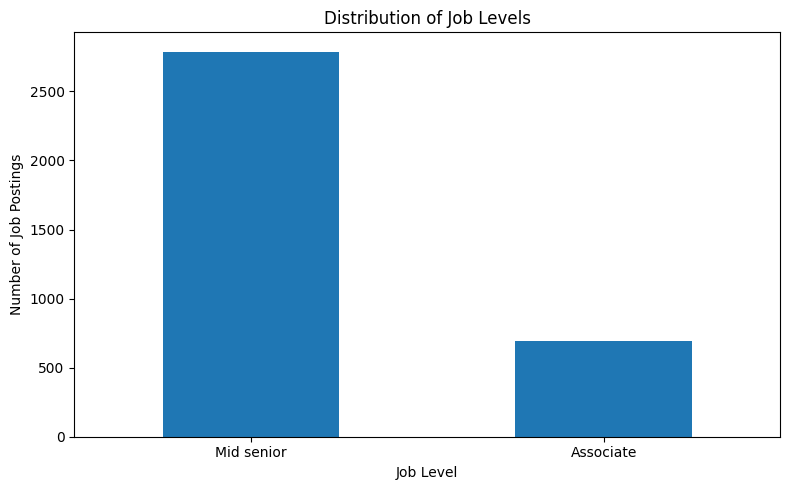

In [391]:
analyst_jobs["job_level"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Job Levels")
plt.xlabel("Job Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The dataset is dominated by Mid senior vacancies, while Associate positions represent a considerably smaller share.

This imbalance highlights why it is important to evaluate whether vacancies labelled as Associate are genuinely suitable for entry-level candidates.

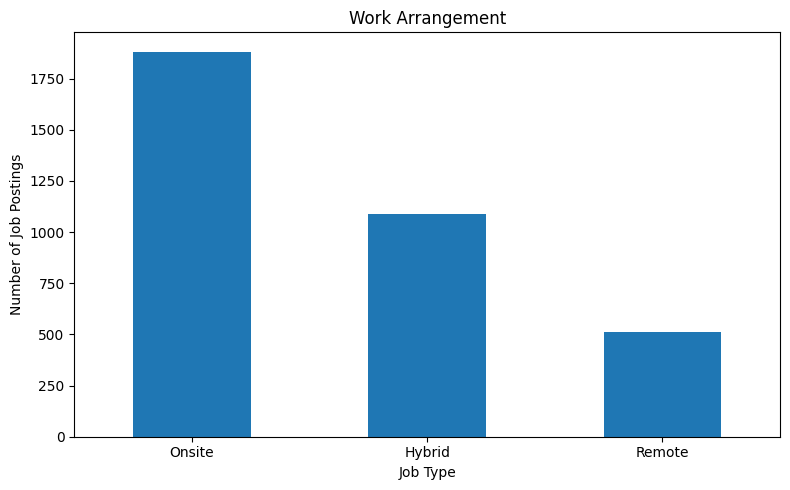

In [392]:
analyst_jobs["job_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Work Arrangement")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Remote, Hybrid, and Onsite work arrangements are represented in the dataset, allowing comparison between different working models.

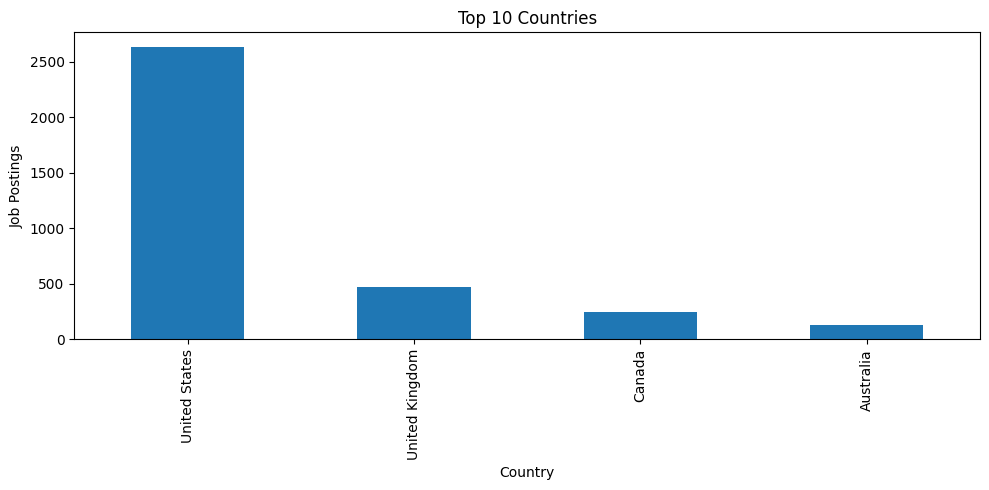

In [393]:
top_countries = analyst_jobs["search_country"].value_counts().head(10)

top_countries.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Job Postings")
plt.tight_layout()
plt.show()

### Interpretation

The majority of vacancies originate from a limited number of countries.

Therefore, regional hiring practices should be considered when interpreting the results.

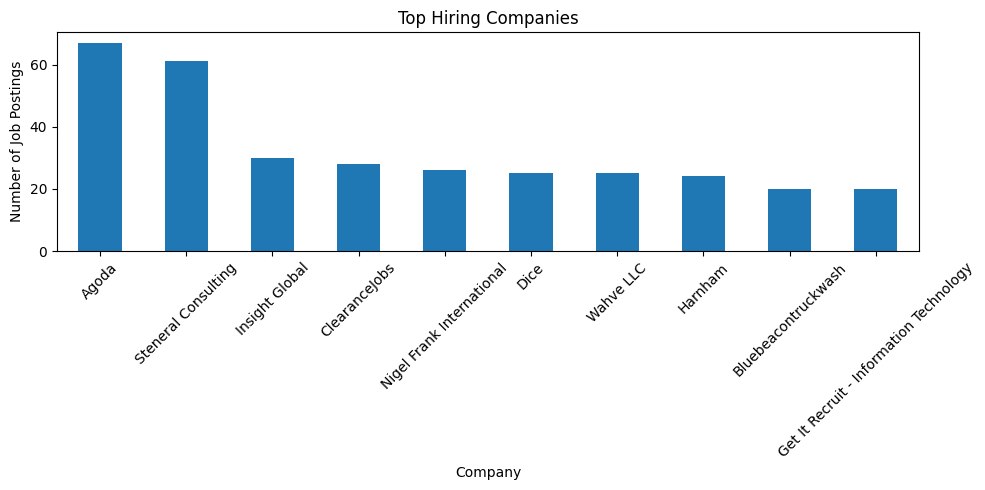

In [394]:
top_companies = analyst_jobs["company"].value_counts().head(10)

top_companies.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

Full-time positions dominate the dataset.

Remote and hybrid work arrangements are also common, indicating increasing flexibility in analyst recruitment.

### Summary

The exploratory analysis confirms that the filtered dataset is suitable for feature engineering and the construction of the Entry-Level Friendliness Index (ELFI).

The following section focuses on transforming unstructured job descriptions into measurable analytical features.

### 5. Feature Engineering

To better understand employer expectations, several new variables were extracted from the job descriptions, including technical skills, experience requirements, leadership expectations, and education requirements.

In [395]:
analyst_jobs["full_text"] = (
    analyst_jobs["job_summary"].fillna("")
    + " "
    + analyst_jobs["job_skills"].fillna("")
)

analyst_jobs["full_text"] = analyst_jobs["full_text"].str.lower()

### Technical Skill Extraction

Technical skills were extracted from the combined vacancy text using regular expressions.

Each detected skill was converted into a binary feature:

- `1` means that the skill is mentioned;
- `0` means that the skill is not mentioned.

Word boundaries were used to reduce accidental partial matches.

In [396]:
skills = {
    "sql": r"\bsql\b",
    "python": r"\bpython\b",
    "excel": r"\bexcel\b",
    "tableau": r"\btableau\b",
    "power_bi": r"\bpower\s*bi\b",
    "statistics": r"\bstatistics?\b",
    "machine_learning": r"\bmachine learning\b",
    "aws": r"\baws\b",
    "azure": r"\bazure\b",
    "spark": r"\bspark\b",
    "etl": r"\betl\b",
}

In [397]:
for skill, pattern in skills.items():
    analyst_jobs[skill] = (
        analyst_jobs["full_text"]
        .str.contains(
            pattern,
            regex=True,
            na=False
        )
        .astype(int)
    )

In [398]:
analyst_jobs[
    [
        "sql",
        "python",
        "excel",
        "tableau",
        "power_bi"
    ]
].head()

,sql,python,excel,tableau,power_bi
1,0,0,1,0,0
5,1,0,0,0,0
31,1,1,0,0,0
37,0,0,0,0,0
38,0,0,0,0,0


In [399]:
skill_columns = list(skills.keys())

analyst_jobs["skills_count"] = (
    analyst_jobs[skill_columns]
    .sum(axis=1)
)

In [400]:
print(f"Number of extracted skill features: {len(skill_columns)}")

Number of extracted skill features: 11


In [401]:
analyst_jobs[
    [
        "job_title",
        "skills_count"
    ]
].head()

,job_title,skills_count
1,Market Research & Insights Analyst,1
5,Business Intelligence Reporting Analyst 2,1
31,Volunteer: Wildfire Prevention Financing Data ...,4
37,Volunteer: Biometric Data Analystat Nature Cou...,1
38,"Volunteer: Medicinal Foods, Volunteer Healthca...",2


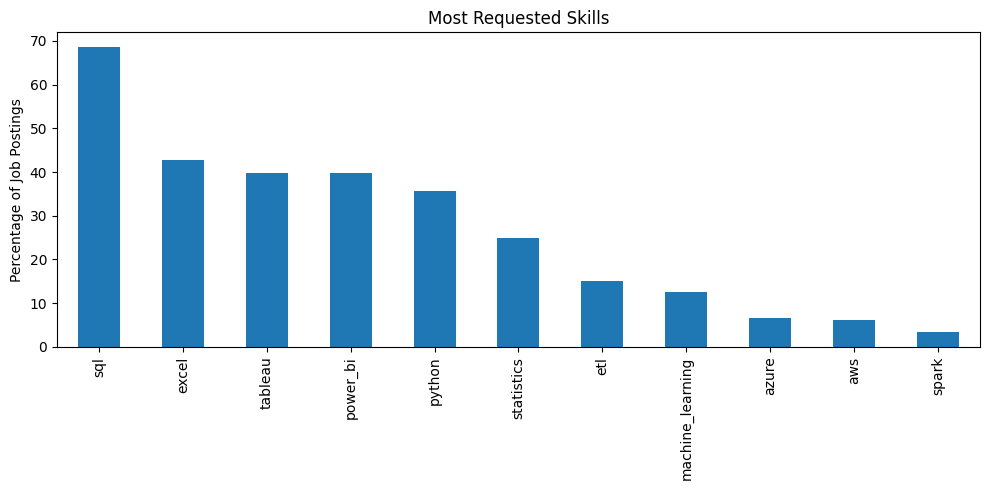

In [443]:
skill_frequency = (
    analyst_jobs[skill_columns]
    .mean()
    .sort_values(ascending=False)
    * 100
)

skill_frequency.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Most Requested Skills")
plt.ylabel("Percentage of Job Postings")
plt.tight_layout()
plt.show()

### Interpretation

SQL is the most frequently requested technical skill in the analysed vacancies.

Excel, Tableau, Power BI, and Python also appear frequently, while cloud technologies and Spark are less common.

The results suggest that core analytical and visualization tools remain more common than highly advanced technologies in Data Analyst vacancies.

## 6. Experience Requirement Detection

To estimate how accessible each position is for beginners, explicit experience requirements were extracted from job descriptions using regular expressions.

In [428]:
def extract_experience_years(text):
    text = str(text).lower()

    patterns = [
        r"(\d+)\s*(?:-|–|to)\s*(\d+)\s*\+?\s*(?:years|year|yrs|yr)",
        r"at least\s+(\d+)\s*\+?\s*(?:years|year|yrs|yr)",
        r"minimum of\s+(\d+)\s*\+?\s*(?:years|year|yrs|yr)",
        r"minimum\s+(\d+)\s*\+?\s*(?:years|year|yrs|yr)",
        r"(\d+)\s*\+?\s*(?:years|year|yrs|yr)\s+of\s+(?:relevant\s+)?experience",
        r"(\d+)\s*\+?\s*(?:years|year|yrs|yr)\s+experience"
    ]

    detected_years = []

    for pattern in patterns:
        matches = re.findall(pattern, text)

        for match in matches:
            if isinstance(match, tuple):
                values = [
                    int(value)
                    for value in match
                    if str(value).isdigit()
                ]

                if values:
                    # For a range such as 3–5 years,
                    # use the lower bound as the minimum requirement.
                    detected_years.append(min(values))
            else:
                detected_years.append(int(match))

    realistic_years = [
        year
        for year in detected_years
        if 0 <= year <= 15
    ]

    return max(realistic_years) if realistic_years else 0

In [429]:
analyst_jobs["experience_years"] = (
    analyst_jobs["full_text"]
    .apply(extract_experience_years)
)

In [430]:
analyst_jobs["experience_years"].describe()

,experience_years
count,3480.000000
mean,1.910057
std,2.656801
min,0.000000
25%,0.000000
50%,0.000000
75%,3.000000
max,15.000000


In [405]:
analyst_jobs["experience_years"].value_counts().sort_index()

,count
experience_years,
0,1225
1,204
2,284
3,397
4,203
5,586
6,98
7,112
8,86


### Interpretation

A value of zero means that no explicit numerical experience requirement was detected in the vacancy description.

This does not necessarily mean that no experience is required.

The extracted values will later contribute to the Entry-Level Friendliness Index (ELFI).

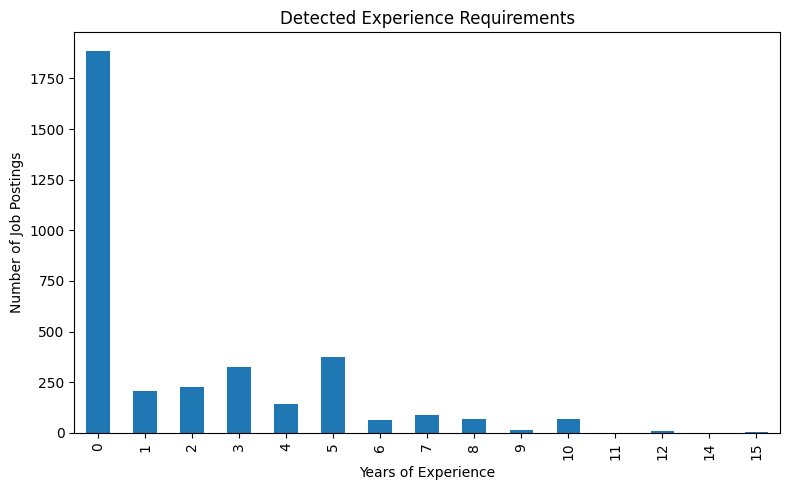

In [431]:
analyst_jobs["experience_years"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Detected Experience Requirements")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Job Postings")
plt.tight_layout()
plt.show()

In [407]:
experience_summary = pd.DataFrame({
    "job_postings": analyst_jobs["experience_years"]
        .value_counts()
        .sort_index(),
    "percentage": analyst_jobs["experience_years"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(1)
})

experience_summary

,job_postings,percentage
experience_years,,
0,1225,35.2
1,204,5.9
2,284,8.2
3,397,11.4
4,203,5.8
5,586,16.8
6,98,2.8
7,112,3.2
8,86,2.5


### Key Insight

Most vacancies do not explicitly mention the required years of experience.

However, among vacancies that specify experience requirements, two or more years are frequently requested. This suggests that many vacancies labelled as Associate may still expect previous professional experience.

## 7. Entry-Level Friendliness Index

The Entry-Level Friendliness Index (ELFI) is a custom score designed to estimate how accessible each vacancy is to early-career candidates.

Each vacancy starts with 100 points. The score is reduced according to explicit experience requirements, the number of requested technical skills, and selected indicators of technical complexity.

Higher ELFI scores indicate vacancies with fewer detected entry barriers. The index is a heuristic comparative metric rather than an official recruitment standard.

In [408]:
experience_penalties = {
    0: 0,
    1: 8,
    2: 15
}

analyst_jobs["experience_penalty"] = (
    analyst_jobs["experience_years"]
    .map(experience_penalties)
)

analyst_jobs.loc[
    analyst_jobs["experience_years"] >= 3,
    "experience_penalty"
] = 25

analyst_jobs["experience_penalty"] = (
    analyst_jobs["experience_penalty"]
    .fillna(0)
)

In [409]:
analyst_jobs["skill_volume_penalty"] = (
    (analyst_jobs["skills_count"] - 5)
    .clip(lower=0)
    * 2
)

In [410]:
analyst_jobs["technical_penalty"] = (
    analyst_jobs["python"] * 2
    + analyst_jobs["statistics"] * 2
    + analyst_jobs["etl"] * 3
)

In [411]:
analyst_jobs["education_penalty"] = 0

In [412]:
analyst_jobs["positive_bonus"] = 0

In [413]:
analyst_jobs["elfi_score"] = (
    100
    - analyst_jobs["experience_penalty"]
    - analyst_jobs["skill_volume_penalty"]
    - analyst_jobs["technical_penalty"]
    - analyst_jobs["education_penalty"]
    + analyst_jobs["positive_bonus"]
)

In [414]:
analyst_jobs["elfi_score"] = (
    analyst_jobs["elfi_score"]
    .clip(lower=0, upper=100)
    .round(1)
)

In [415]:
print(f"Minimum ELFI: {analyst_jobs['elfi_score'].min():.1f}")
print(f"Maximum ELFI: {analyst_jobs['elfi_score'].max():.1f}")
print(f"Missing ELFI values: {analyst_jobs['elfi_score'].isna().sum()}")

Minimum ELFI: 58.0
Maximum ELFI: 100.0
Missing ELFI values: 0


In [432]:
analyst_jobs["elfi_score"].describe()

,elfi_score
count,3480.000000
mean,83.639943
std,11.905128
min,58.000000
25%,73.000000
50%,75.000000
75%,98.000000
max,100.000000


In [416]:
def classify_elfi(score):
    if score >= 85:
        return "Highly entry-level friendly"
    elif score >= 70:
        return "Entry-level friendly"
    elif score >= 50:
        return "Questionable"
    else:
        return "Entry-level in name only"


analyst_jobs["elfi_category"] = (
    analyst_jobs["elfi_score"]
    .apply(classify_elfi)
)

In [417]:
analyst_jobs[
    [
        "job_title",
        "job_level",
        "experience_years",
        "skills_count",
        "experience_penalty",
        "skill_volume_penalty",
        "technical_penalty",
        "education_penalty",
        "positive_bonus",
        "elfi_score",
        "elfi_category"
    ]
].head(10)

,job_title,job_level,experience_years,skills_count,experience_penalty,skill_volume_penalty,technical_penalty,education_penalty,positive_bonus,elfi_score,elfi_category
1,Market Research & Insights Analyst,Mid senior,5,1,25.0,0,0,0,0,75.0,Entry-level friendly
5,Business Intelligence Reporting Analyst 2,Mid senior,3,1,25.0,0,0,0,0,75.0,Entry-level friendly
31,Volunteer: Wildfire Prevention Financing Data ...,Associate,0,4,0.0,0,4,0,0,96.0,Highly entry-level friendly
37,Volunteer: Biometric Data Analystat Nature Cou...,Associate,0,1,0.0,0,0,0,0,100.0,Highly entry-level friendly
38,"Volunteer: Medicinal Foods, Volunteer Healthca...",Associate,0,2,0.0,0,2,0,0,98.0,Highly entry-level friendly
40,Volunteer: Data Visualization / Business Intel...,Associate,0,6,0.0,2,4,0,0,94.0,Highly entry-level friendly
41,Volunteer: Data Visualization / Business Intel...,Associate,0,5,0.0,0,2,0,0,98.0,Highly entry-level friendly
43,Business Intelligence Analyst,Mid senior,5,6,25.0,2,5,0,0,68.0,Questionable
44,Business Intelligence Analyst,Mid senior,7,6,25.0,2,2,0,0,71.0,Entry-level friendly
45,Business Intelligence Analyst,Mid senior,5,6,25.0,2,5,0,0,68.0,Questionable


Interpretation

The ELFI score combines multiple factors into a single metric that estimates how accessible a vacancy is for entry-level candidates.

Higher scores indicate fewer barriers, such as lower experience requirements and fewer advanced technical demands. Lower scores suggest that the vacancy may be labelled as entry-level but still requires substantial experience or advanced skills.

This score will be used in the following section to compare different groups of vacancies and identify overall hiring trends.

## 8. Associate Vacancy Results

This section focuses specifically on vacancies advertised at the Associate level.

The ELFI score is used to evaluate how accessible these positions appear to early-career candidates and to identify cases where the advertised level may conflict with the actual requirements.

In [433]:
associate_jobs = (
    analyst_jobs[
        analyst_jobs["job_level"] == "Associate"
    ]
    .copy()
)

print(f"Associate analyst jobs: {len(associate_jobs):,}")

Associate analyst jobs: 692


In [419]:
associate_jobs["elfi_score"].describe()

,elfi_score
count,692.000000
mean,86.109827
std,11.979460
min,44.000000
25%,75.000000
50%,86.500000
75%,98.000000
max,100.000000


### Score Distribution

The average ELFI score provides an overall estimate of how accessible Associate vacancies appear to entry-level applicants.

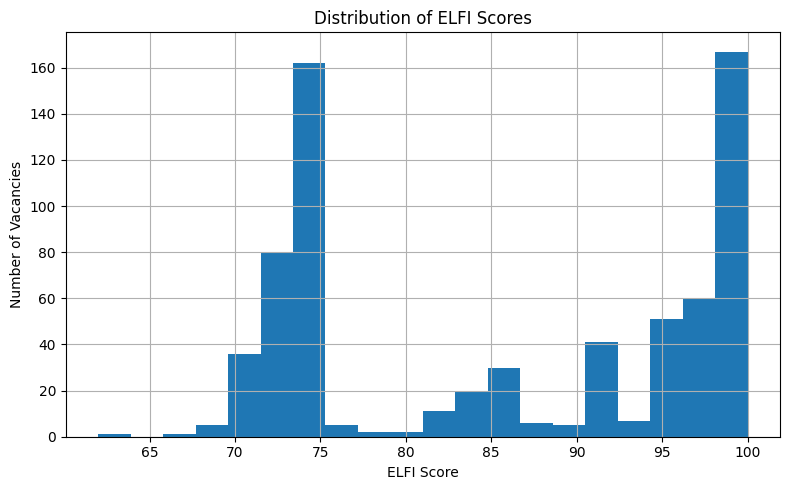

In [434]:
associate_jobs["elfi_score"].hist(
    bins=20,
    figsize=(8,5)
)

plt.title("Distribution of ELFI Scores")
plt.xlabel("ELFI Score")
plt.ylabel("Number of Vacancies")
plt.tight_layout()
plt.show()

### Interpretation

Most Associate vacancies fall within the middle range of ELFI scores, indicating that accessibility varies considerably across employers.

Some vacancies appear genuinely entry-level, while others include substantial hiring barriers.

### Most Entry-Level-Friendly Vacancies

The following table presents the highest-scoring Associate vacancies.

When multiple vacancies have the same ELFI score, positions with lower experience requirements and fewer detected technical skills are ranked higher.

In [438]:
best_jobs = (
    associate_jobs[
        [
            "job_title",
            "company",
            "job_location",
            "experience_years",
            "skills_count",
            "elfi_score",
            "elfi_category"
        ]
    ]
    .sort_values(
        ["elfi_score", "experience_years", "skills_count"],
        ascending=[False, True, True]
    )
    .head(10)
)

best_jobs

,job_title,company,job_location,experience_years,skills_count,elfi_score,elfi_category
240,Vendor Data Analyst,The University of Texas at Dallas,"Richardson, TX",0,0,100.0,Highly entry-level friendly
259,Data Analyst,Steneral Consulting,"Richardson, TX",0,0,100.0,Highly entry-level friendly
500,eDiscovery Data Analyst,Kellton,"Boston, MA",0,0,100.0,Highly entry-level friendly
710,Data Analyst,Accroid Inc,"West Chester, PA",0,0,100.0,Highly entry-level friendly
722,StrataJazz / EPSI Data Analyst (Remote Option),"Liberty Personnel Services, Inc.","Philadelphia, PA",0,0,100.0,Highly entry-level friendly
1051,MAOP Data Analyst,Acadian Ambulance,"Houston, TX",0,0,100.0,Highly entry-level friendly
1568,Business Data Analyst,Enexus Global Inc.,United States,0,0,100.0,Highly entry-level friendly
1581,Data Analyst,Cypress HCM,United States,0,0,100.0,Highly entry-level friendly
1876,Remote Business Data Analyst,Kforce Inc,"Los Angeles, CA",0,0,100.0,Highly entry-level friendly
1891,Oracle Senior Reporting Analyst,Steneral Consulting,United States,0,0,100.0,Highly entry-level friendly


### Interpretation

The highest-scoring vacancies generally contain no explicit experience requirement and request a relatively limited technical skill set.

These positions appear to present the fewest detected barriers for early-career candidates. However, a high ELFI score does not guarantee that the vacancy is genuinely junior-friendly, because some requirements may not be explicitly stated in the job description.

### Least Entry-Level-Friendly Vacancies

The following table presents the lowest-scoring Associate vacancies.

These positions combine stronger experience requirements, broader technical expectations, or other detected entry barriers.

In [437]:
worst_jobs = (
    associate_jobs[
        [
            "job_title",
            "company",
            "job_location",
            "experience_years",
            "skills_count",
            "experience_penalty",
            "skill_volume_penalty",
            "technical_penalty",
            "elfi_score",
            "elfi_category"
        ]
    ]
    .sort_values(
        ["elfi_score", "experience_years", "skills_count"],
        ascending=[True, False, False]
    )
    .head(10)
)

worst_jobs

,job_title,company,job_location,experience_years,skills_count,experience_penalty,skill_volume_penalty,technical_penalty,elfi_score,elfi_category
1271,Data Analyst,Rezilient Health,"St Louis, MO",2,8,25.0,6,7,62.0,Questionable
3582,Data Analyst- EN,CN,"Homewood, IL",3,7,25.0,4,4,67.0,Questionable
1880,Senior Reporting Data Analyst,Kforce Inc,"Los Angeles, CA",5,6,25.0,2,5,68.0,Questionable
12228,Reporting Analyst,Roy Morgan,"Melbourne, Victoria, Australia",2,6,25.0,2,5,68.0,Questionable
2248,REMOTE Role in TX :: Data Analyst :: Exp'5+,TekIntegral,United States,2,4,25.0,0,7,68.0,Questionable
8418,Business Intelligence Analyst,Navacord,"Ontario, Canada",3,6,25.0,2,4,69.0,Questionable
8492,Data Analyst,SmartChoice International Limited,"Newbury, England, United Kingdom",3,6,25.0,2,4,69.0,Questionable
1555,Data Analyst,SmartIPlace,United States,10,4,25.0,0,5,70.0,Entry-level friendly
10050,Technical Data Analyst,System One,"Des Moines, IA",6,4,25.0,0,5,70.0,Entry-level friendly
2418,Data Analyst //Pay rate: $43.35/hr,Stellar Professionals,"Indianapolis, IN",5,5,25.0,0,5,70.0,Entry-level friendly


### Interpretation

The lowest-scoring vacancies frequently require several years of experience or a broad technical skill set despite being labelled as Associate positions.

These examples support the main hypothesis of the project: the advertised seniority label alone does not always accurately represent how accessible a vacancy is to entry-level candidates.

# 9. ELFI Comparison

This section compares the average ELFI score across countries and work arrangements to identify broader differences in the accessibility of Associate vacancies.

The number of vacancies in each group is also reported because averages based on small samples should be interpreted cautiously.

## 9.1 ELFI by Country

In [440]:
country_scores = (
    associate_jobs
    .groupby("search_country")
    .agg(
        average_elfi=("elfi_score", "mean"),
        median_elfi=("elfi_score", "median"),
        vacancies=("elfi_score", "count")
    )
    .round(1)
    .sort_values("average_elfi", ascending=False)
)

country_scores

,average_elfi,median_elfi,vacancies
search_country,,,
United Kingdom,90.5,96.0,81
United States,85.8,85.0,558
Australia,84.8,85.0,25
Canada,83.6,82.0,28


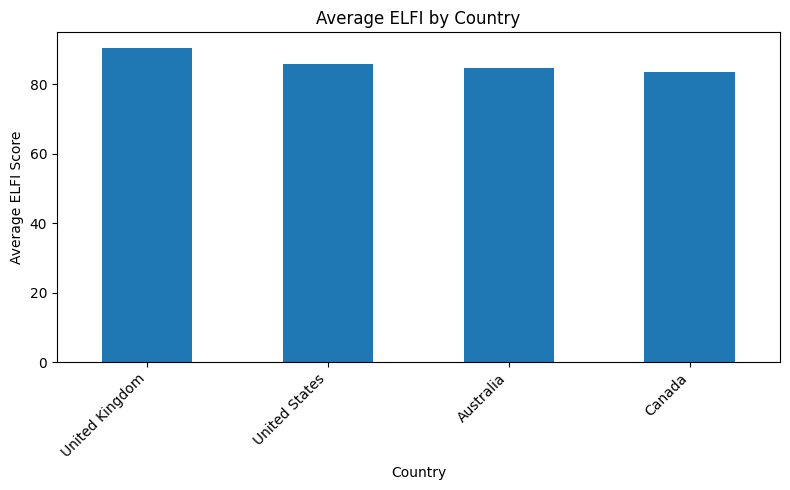

In [441]:
country_scores["average_elfi"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average ELFI by Country")
plt.xlabel("Country")
plt.ylabel("Average ELFI Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

Average ELFI scores differ across countries, suggesting that the detected accessibility of Associate vacancies may vary between labour markets.

However, these differences should be interpreted cautiously because the number of vacancies is not equal across countries. Groups with smaller samples may produce less stable average scores, so both the ELFI value and vacancy count should be considered.

## 9.2 ELFI by Work Arrangement

In [442]:
work_summary = (
    associate_jobs
    .groupby("job_type")
    .agg(
        average_elfi=("elfi_score", "mean"),
        median_elfi=("elfi_score", "median"),
        vacancies=("elfi_score", "count")
    )
    .round(1)
    .sort_values("average_elfi", ascending=False)
)

work_summary

,average_elfi,median_elfi,vacancies
job_type,,,
Onsite,87.1,92.0,315
Remote,86.0,83.0,108
Hybrid,85.2,83.0,269


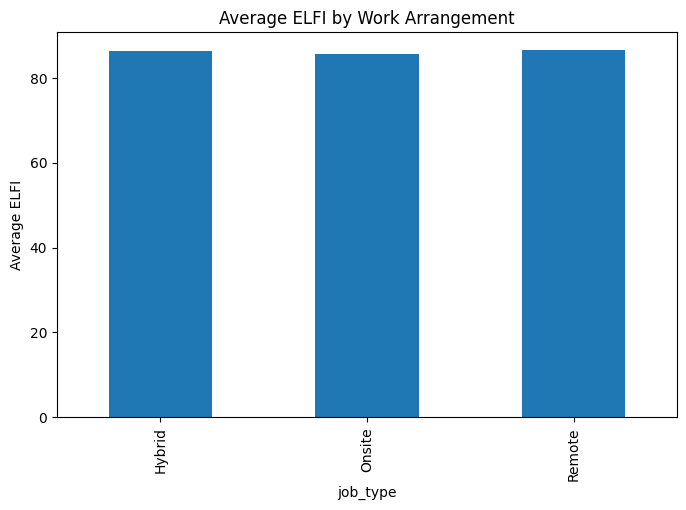

In [426]:
work_summary["average_elfi"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average ELFI by Work Arrangement")
plt.xlabel("Work Arrangement")
plt.ylabel("Average ELFI Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

Average ELFI scores may differ between onsite, hybrid, and remote vacancies.

However, work arrangement should not be treated as a direct measure of entry-level accessibility. ELFI is primarily influenced by experience requirements and technical complexity, while the observed differences between work arrangements may also reflect differences in employers, locations, and sample sizes.

### Section Summary

The comparison reveals variation in ELFI across both countries and work arrangements.

These results provide useful context, but they do not establish that location or working model directly causes a vacancy to be more entry-level friendly. The comparisons should therefore be interpreted as descriptive patterns rather than causal relationships.

# 10. Key Findings

The analysis produced several important insights regarding entry-level Data Analyst vacancies.

- SQL remains the most frequently requested technical skill, followed by Excel, Tableau, Power BI, and Python.

- Experience requirements vary considerably. While many Associate vacancies appear suitable for junior candidates, a substantial proportion still requires two or more years of professional experience.

- The Entry-Level Friendliness Index (ELFI) demonstrates that vacancies with the same advertised seniority level can differ significantly in their actual accessibility.

- Technical complexity, experience requirements, and seniority-related language are the strongest factors reducing ELFI scores.

- The analysis suggests that job titles alone are not sufficient to evaluate whether a vacancy is genuinely entry-level.

# 11. Conclusion

This project investigated whether Data Analyst vacancies labelled as Associate are genuinely suitable for early-career candidates.

Using Python, feature engineering, regular expressions, and exploratory data analysis, unstructured job descriptions were transformed into structured analytical variables.

The proposed Entry-Level Friendliness Index (ELFI) combines multiple aspects of each vacancy, including experience requirements, technical complexity, education requirements, seniority-related language, and positive junior-friendly signals.

The results show that although many Associate vacancies are relatively accessible, others include requirements that are more typical of experienced professionals.

Overall, the project demonstrates how analytical techniques can be used to transform textual recruitment data into interpretable business insights and support evidence-based evaluation of labour market trends.

# 12. Limitations and Future Improvements

Although the proposed ELFI provides a structured approach for evaluating entry-level accessibility, several limitations should be acknowledged.

## Limitations

- The dataset represents vacancies collected during a specific period and may not reflect future labour market conditions.

- Job descriptions were analysed using regular expressions, meaning that some alternative wording may not have been detected.

- ELFI is a heuristic analytical metric rather than an official recruitment standard.

- The meaning of the Associate label differs between companies and countries.

- Job advertisements do not necessarily reflect the complete hiring process or the final expectations discussed during interviews.

## Future Improvements

Possible improvements include:

- collecting a larger and more recent dataset;
- incorporating salary information;
- using Natural Language Processing instead of rule-based extraction;
- validating ELFI against manually labelled vacancies;
- performing sensitivity analysis of the scoring weights.

# 13. Exporting the Final Dataset

The final enriched dataset, containing all engineered variables and ELFI scores, is exported for future analysis, dashboard development, or business intelligence applications.

In [427]:
associate_jobs.to_csv(
    "ELFI_Data_Analyst_Project.csv",
    index=False
)

print("Dataset successfully exported.")

Dataset successfully exported.
